# 4. The spectral route to the central charge

The second route to $c$ uses no eigenvectors. The leading eigenvalue $\mu_0(T)$ of the transfer
matrix carries a phase, and CFT fixes how that phase varies along the $T$ ladder,

$$\frac{\varphi(T)}{T} = a_0 - \frac{\pi}{T} + \frac{C}{T^2},
\qquad c = \frac{24\,v\,|C|}{\pi},$$

with $v(p)$ taken from equilibrium in notebook 1. The extensive term $a_0$ is not universal. The
$-\pi/T$ term is the branch offset of $\lambda_0 = \log(-\mu_0)$ and is pinned rather than fitted;
released, it returns $B/\pi = -1.0000$, so it carries no physics. The $1/T^2$ curvature is the
measurement.

In [1]:
include("../src/thesislib.jl")
using JLD2, Printf, Statistics, LsqFit
thesis_plot_theme!()

## One eigenvalue

Every point on the ladder is one eigenvalue of one transfer matrix. The cell below builds the column
at $p = 0$ and $T = 3$, runs the block iteration on it, and reports the leading eigenvalue and its
phase. The production ladder repeats this call at every $T$ on the grid.

In [2]:
mpo, scaffold = build_alcaraz_tmpo(3.0; p=0.0, dt=0.1, nbeta=4, column=:bulk5)
theta, L, R, info = block_transfer_eigs(mpo, scaffold; k=4, maxdim=32, eps_conv=1e-6, itermax=150)

i0 = argmax(abs.(theta))
@printf("k = %d Ritz values; leading |mu0| = %.5f, arg(-mu0) = %.5f\n",
        length(theta), abs(theta[i0]), angle(-theta[i0]))

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=154|"S=1/2,Site") <-> (dim=2|id=154|"S=1/2,Site")'


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=50|"Link,l=1") <-> (dim=3|id=627|"Link,l=2"), normdiff = 0.9446880731519559
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
[ Info: Tensor symmetric (dim=2|id=914|"S=1/2,Site") <-> (dim=2|id=914|"S=1/2,Site")'


k = 4 Ritz values; leading |mu0| = 1.49225, arg(-mu0) = 0.67355


[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=3|id=130|"Link,l=1") <-> (dim=3|id=797|"Link,l=2"), normdiff = 0.10493384159131464
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93


## The fit

We collect $\arg(-\mu_0)$ along the ladder, unwrap it so that the branch stays continuous, divide by
$T$ and fit

$$\frac{\varphi(T)}{T} = a_0 - \frac{\pi}{T} + \frac{C}{T^2},$$

with the constant pinned to $-\pi$, since it is the branch offset of the logarithm rather than a
free parameter. Then $c = 24\,v\,|C|/\pi$. At $p = 0$ both $c = 1/2$ and $v = 2$ are known exactly,
so this is a control.

31 rungs   a0 = 1.27509   C = -0.029529   ->   c = 24 v |C| / pi = 0.4512   (Ising: 0.5)


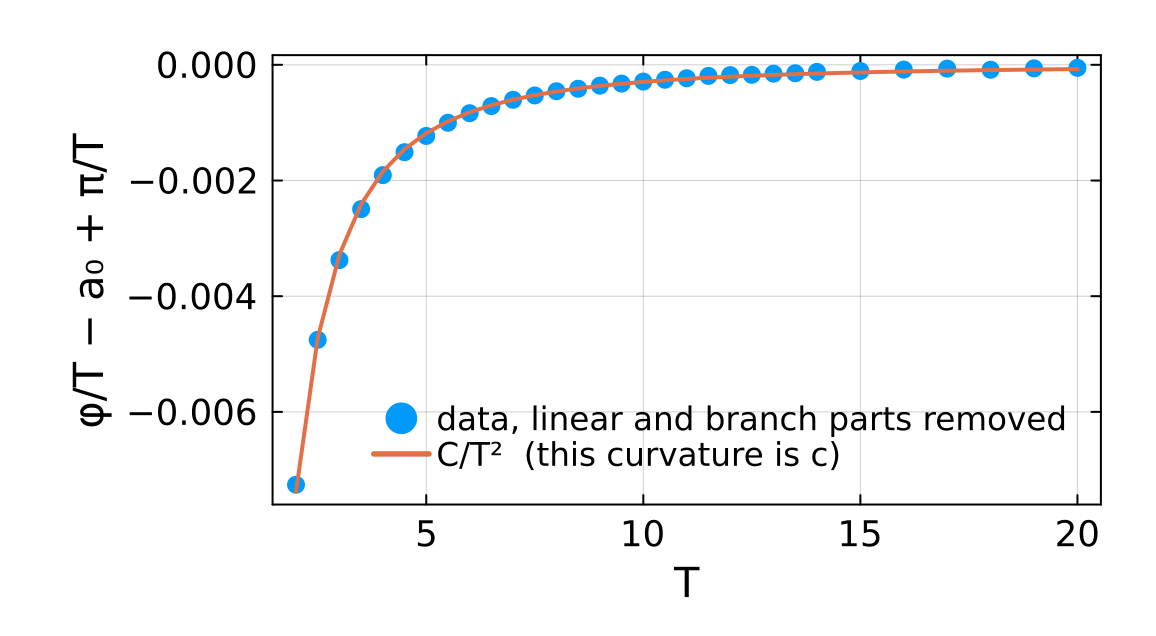

In [3]:
arm(file, label) = Dict(k[2] => v for (k, v) in load(joinpath("../data/cluster", file), "done")
                        if k[1] == label && !haskey(v, :error))
ladder = merge(arm("sweep_rtm_eigs_p0.0.jld2", "rtm_eigs_p0.0"),
               arm("sweep_rtm_eigs_p0.0_fine.jld2", "rtm_eigs_p0.0_fine"))

Ts  = sort([T for T in keys(ladder) if 2 <= T <= 22])
phi = [angle(-ladder[T].theta_phys) for T in Ts]
for i in 2:length(phi)                       # unwrap: keep the branch continuous in T
    phi[i] = phi[i-1] + mod(phi[i] - phi[i-1] + pi, 2pi) - pi
end

@. eq3(T, q) = q[1] - pi / T + q[2] / T^2    # q = (a0, C), the -pi is the pinned branch
fit = curve_fit(eq3, Ts, phi ./ Ts, [0.1, -0.01])
@printf("%d rungs   a0 = %.5f   C = %.6f   ->   c = 24 v |C| / pi = %.4f   (Ising: 0.5)\n",
        length(Ts), fit.param[1], fit.param[2], 24 * 2.0 * abs(fit.param[2]) / pi)

pl = plot(Ts, phi ./ Ts .- fit.param[1] .+ pi ./ Ts; seriestype=:scatter, ms=5, msw=0,
          label="data, linear and branch parts removed", xlabel="T", ylabel="φ/T − a₀ + π/T",
          size=thesis_size(0.75; aspect=0.55))
plot!(pl, Ts, fit.param[2] ./ Ts .^ 2; lw=2, label="C/T²  (this curvature is c)")

## The four couplings

First, $\mu_0$ in the complex plane: the
modulus is constant while the phase advances, which is why the phase carries the measurement. Below, the fit at each coupling with the extensive term subtracted, so that the curvature carrying
$c$ is visible.

p=0.0  |mu0| = 1.4873  (spread 1.46e-02)
p=0.1  |mu0| = 1.5556  (spread 1.10e-02)


p=0.3  |mu0| = 1.7042  (spread 9.72e-03)
p=0.5  |mu0| = 1.8648  (spread 3.58e-03)
p=0.0  32 rungs T=2..22  c = 0.4512
p=0.1  24 rungs T=2..17  c = 0.4689


p=0.3  14 rungs T=2..10  c = 0.4921
p=0.5   9 rungs T=2..6  c = 0.5332


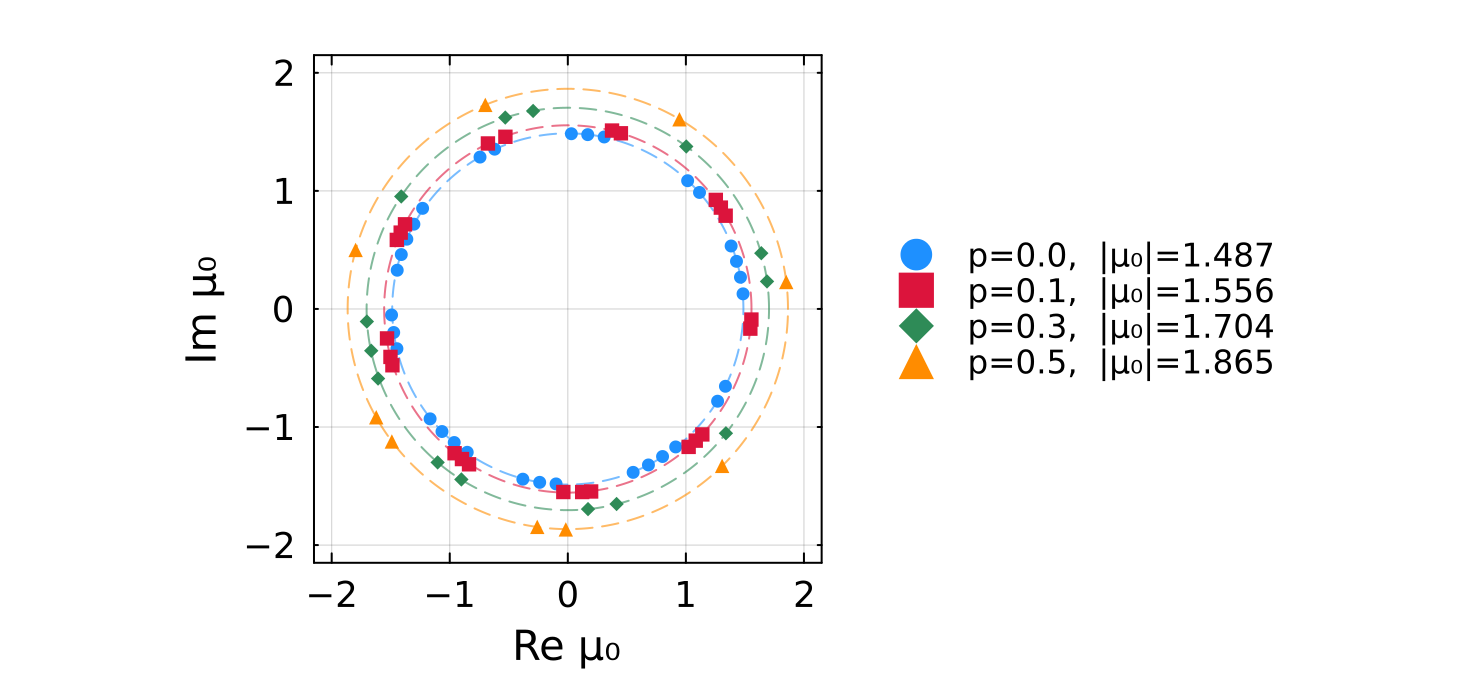

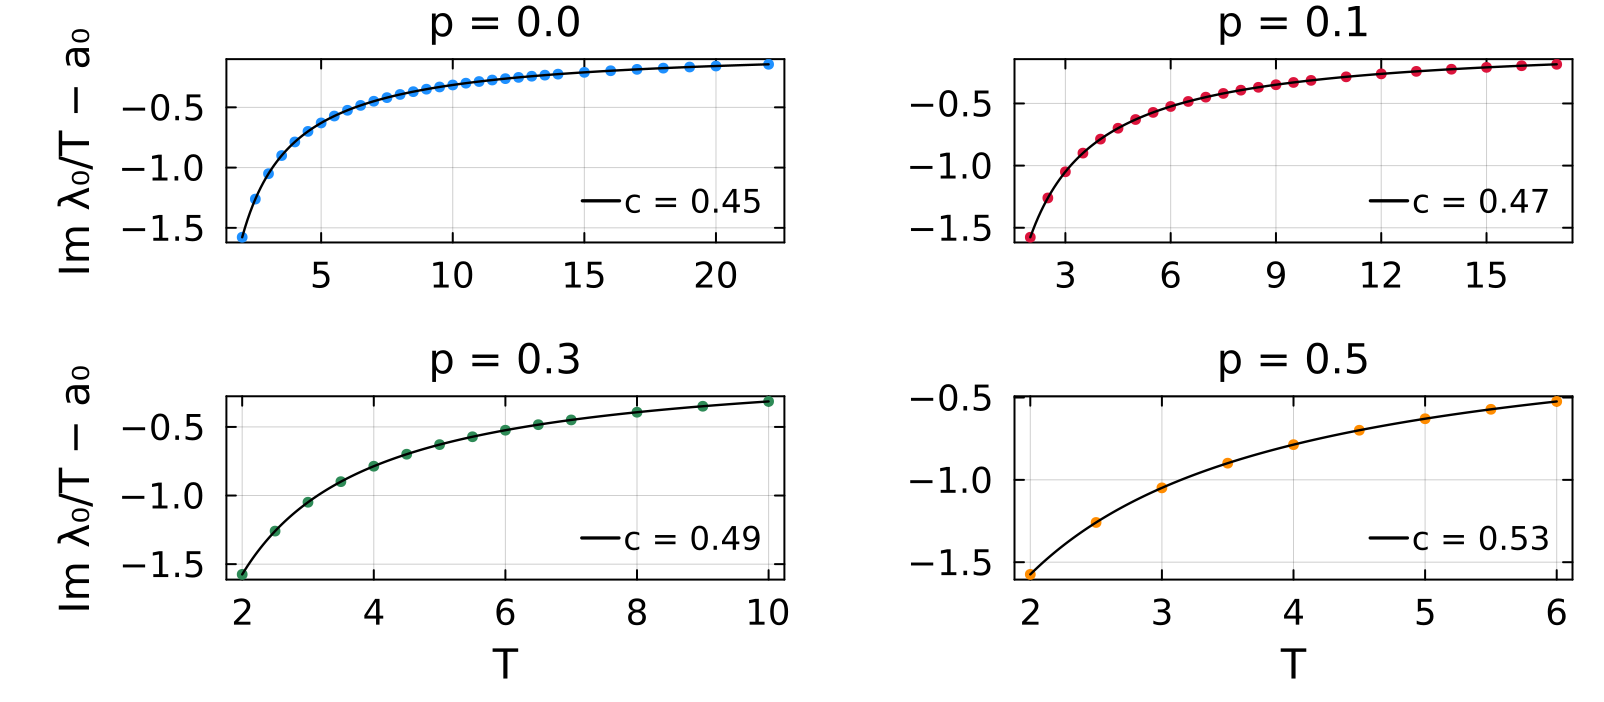

In [4]:
include("../scripts/figures/fig_spectral.jl")
sp = make_spectral()
display(sp.circle)
sp.eq3

## The coefficient deficit

The fitted central charges are $c = 0.45, 0.47, 0.49, 0.53$ at $p = 0, 0.1, 0.3, 0.5$. At $p = 0$,
where $c = 1/2$ and $v = 2$ are exact, the fitted $1/T^2$ coefficient is 5 to 10 per cent below the
CFT prediction, which is the same effect as reading $c = 0.45$ instead of $0.50$. Two tests identify
the origin as the truncation of the expansion behind the fitted form. Including one more order in
$1/T$ raises the coefficient from 90 to 97 per cent of the prediction. The coefficient also falls
linearly with the cooling regulator $\beta_0$, and extrapolating to $\beta_0 \to 0$ gives 1.013 of
the CFT value.

intercept at beta0=0: 1.013   slope -0.668


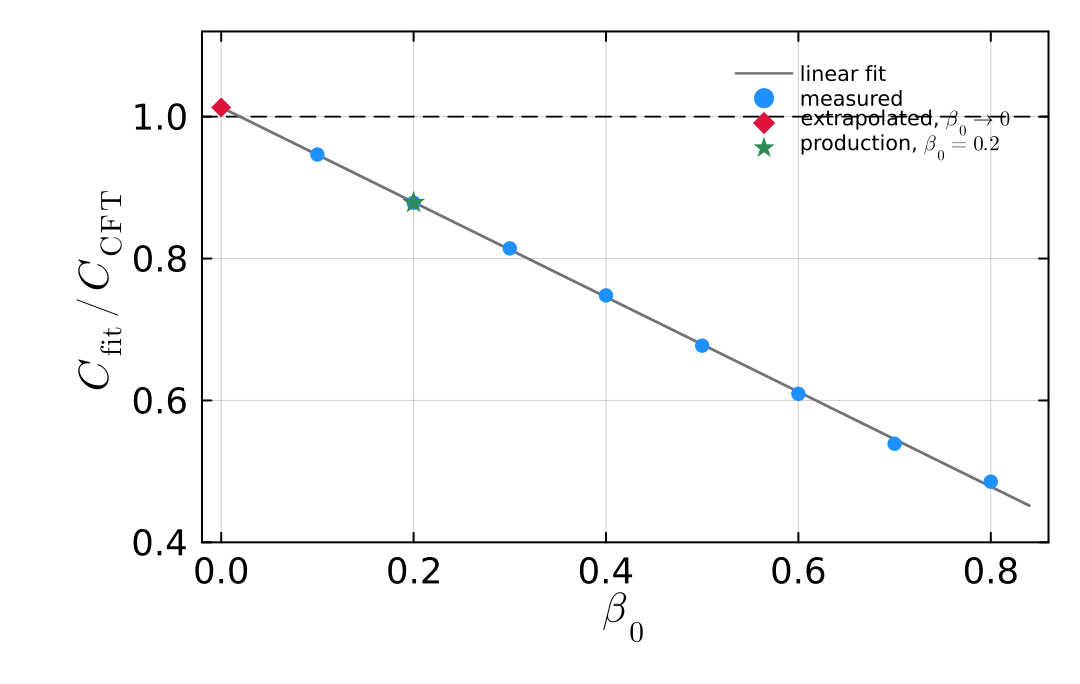

In [6]:
# the beta0 scan behind fig:beta0, from data/cluster/sweep_beta_p0.0.jld2
include("../scripts/figures/fig_beta0.jl")
make_beta0()

The production point at $\beta_0 = 0.2$ lies on the linear trend. The deficit is systematic and
accounted for, and the table reports the fitted values with the deficit stated alongside.

## Comparison with the integrable point

The $p = 0$ row is exactly solvable and the rest is interacting. Every column is measured with the
same machinery.

| p | c (equilibrium DMRG) | c (spectral, dynamics) | x₁ measured | x₁ CFT |
|---|---|---|---|---|
| 0.0 | 0.502 | 0.45 | 0.498 | 1/2 |
| 0.1 | 0.502 | 0.47 | 0.497 | 1/2 |
| 0.3 | 0.502 | 0.49 | 0.493 | 1/2 |
| 0.5 | 0.502 | 0.53 | 0.487 | 1/2 |

The spectral route is also more robust where the entropy route is fragile. At $p = 0.3$ and
$T = 6, 6.5, 7$, six independent cold seeds per rung all converge, with phases agreeing to about
$10^{-4}$. The statistics are in notebook 6.

## The audit

The script below recomputes every number the thesis quotes from the cluster caches alone: central
charges, windows, boundary dimensions and plateau readings.

In [7]:
# recomputes every number of the results table from the cluster caches alone
include("../scripts/analysis/cluster_audit.jl")

=== 1. entropy plateau, and where each ladder stops ===


p=0.0  T=2-18  clean to 15
   

┌ Warning: Assignment to `Ts` in soft scope is ambiguous because a global variable by the same name exists: `Ts` will be treated as a new local. Disambiguate by using `local Ts` to suppress this warning or `global Ts` to assign to the existing global variable.
└ @ ~/Desktop/masters/master-thesis-BSC/scripts/analysis/cluster_audit.jl:37


2:0.1334  3:0.1314  4:0.1300  5:0.1287  6:0.1289  7:0.1227  8:0.1243  9:0.1241  10:0.1218  11:0.1249  12:0.1221  13:0.1170  14:0.1218  15:0.1175  16:-1.6831  17:2.8569  18:1.6852
p=0.1  T=2-9.5  clean to 9.5
   2:0.1335  2.5:0.1335  3:0.1332  3.5:0.1345  4:0.1344  4.5:0.1338  5:0.1314  5.5:0.1288  6:0.1285  6.5:0.1273  7:0.1307  7.5:0.1289  8:0.1287  8.5:0.1270  9:0.1258  9.5:0.1198
p=0.3  T=2-7.5  clean to 7.5
   2:0.1437  2.5:0.1363  3:0.1350  3.5:0.1347  4:0.1323  4.5:0.1315  5:0.1328  5.5:0.1319  6:0.1320  6.5:0.1281  7:0.1260  7.5:0.1307
p=0.5  T=2-6  clean to 6
   2:0.1460  2.5:0.1346  3:0.1341  3.5:0.1373  4:0.1372  4.5:0.1414  5:0.1244  5.5:0.1348  6:0.1398
p=1.0  T=2-3.25  clean to 3.25
   2:0.1366  2.25:0.1341  2.5:0.1325  2.75:0.1333  3:0.1340  3.25:0.1366

=== 2. the Bou-Comas extrapolation of the plateau, cluster ladders ===
p=0.0  14 rungs T=2-15   sqrtT: a=0.1117 -> c=0.569   two-term: a=0.1141 -> c=0.581

┌ Warning: Assignment to `Ts` in soft scope is ambiguous because a global variable by the same name exists: `Ts` will be treated as a new local. Disambiguate by using `local Ts` to suppress this warning or `global Ts` to assign to the existing global variable.
└ @ ~/Desktop/masters/master-thesis-BSC/scripts/analysis/cluster_audit.jl:56


...

┌ Warning: Assignment to `Ts` in soft scope is ambiguous because a global variable by the same name exists: `Ts` will be treated as a new local. Disambiguate by using `local Ts` to suppress this warning or `global Ts` to assign to the existing global variable.
└ @ ~/Desktop/masters/master-thesis-BSC/scripts/analysis/cluster_audit.jl:155


p=0.5  last T=4.5  x = 0.487, 1.499, 2.013
p=1.0  last T=3  x = 0.494, 1.568, 2.140

=== 7. what Table 1 quotes, and where each column comes from ===
  spectral c: block-iteration rungs continued with single-vector rungs
  p     window       pts     c         rms
  0.0   T<=22        32      0.4512    3.9e-05
  0.1   T<=17        24      0.4689    2.6e-05
  0.3   T<=10        14      0.4921    1.4e-05
  0.5   T<=6         9       0.5332    5.8e-05

  entropy-route c: local single-vector seed ensembles, median plateau per rung


  p     window       rungs   c         surviving fraction per rung
  0.0   8.0-24.0     10      0.4983    8.0:20/20 10.0:20/20 12.0:20/20 14.0:20/20 16.0:20/20 17.0:20/20 18.0:19/20 20.0:20/20 22.0:18/20 24.0:16/20
  0.1   4.0-13.0     10      0.4965    4.0:10/10 5.0:10/10 6.0:10/10 7.0:10/10 8.0:10/10 9.0:10/10 10.0:10/10 11.0:8/10 12.0:10/10 13.0:10/10


┌ Warning: Assignment to `Ts` in soft scope is ambiguous because a global variable by the same name exists: `Ts` will be treated as a new local. Disambiguate by using `local Ts` to suppress this warning or `global Ts` to assign to the existing global variable.
└ @ ~/Desktop/masters/master-thesis-BSC/scripts/analysis/cluster_audit.jl:192
┌ Warning: Assignment to `fit` in soft scope is ambiguous because a global variable by the same name exists: `fit` will be treated as a new local. Disambiguate by using `local fit` to suppress this warning or `global fit` to assign to the existing global variable.
└ @ ~/Desktop/masters/master-thesis-BSC/scripts/analysis/cluster_audit.jl:202


  0.3   2.0-9.0      10      0.5294    2.0:10/10 2.5:10/10 3.0:10/10 3.5:10/10 4.0:10/10 5.0:10/10 6.0:10/10 7.0:8/10 8.0:14/20 9.0:9/20
  0.5   2.0-5.0      7       0.5774    2.0:10/10 2.5:10/10 3.0:10/10 3.5:8/10 4.0:7/10 4.5:4/10 5.0:3/10
